# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [1]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 136 packages in 1.30s
Checked 136 packages in 4ms


## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [3]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-07-08 15:34:28 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-07-08 15:34:31 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set trea

In [1]:
!pip install --force-reinstall --no-deps torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0

  Using cached torch-2.6.0-cp312-cp312-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached torchvision-0.21.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.1 kB)
  Using cached torchaudio-2.6.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.6 kB)
Using cached torch-2.6.0-cp312-cp312-manylinux1_x86_64.whl (766.6 MB)
Using cached torchvision-0.21.0-cp312-cp312-manylinux1_x86_64.whl (7.2 MB)
Using cached torchaudio-2.6.0-cp312-cp312-manylinux1_x86_64.whl (3.4 MB)
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.6.0
    Uninstalling torchaudio-2.6.0:
      Successfully uninstalled torchaudio-2.6.0
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.21.0
    Uninstalling torchvision-0.21.0:
      Successfully uninstalled torchvision-0.21.0
  Attempting uninstall: torch
    Found existing installation: torch 2.6.0
    Uninstalling torch-2.6.0:
      Successfully uninstalled torch-2.6.0


## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [4]:
video_path = CACHE_FOLDER / "sample_video.mp4"
url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
download_file(url, video_path)
df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
INFO:tribev2.demo_utils:Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 1999.19it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [00:00<00:00, 223.16it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 30/30 [00:00<00:00, 40291.10it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,52.210000,cache/sample_video.wav,NaN,
1,Video,0.000000,52.210000,cache/sample_video.mp4,NaN,
2,Sentence,12.212999,2.042002,NaN,What brings you to the land of the gatekeepers?.,
3,Text,12.213000,31.490000,NaN,What brings you to the land of the gatekeepers...,
4,Word,12.213000,0.120000,NaN,What,What
5,Word,12.393000,0.280000,NaN,brings,What brings
6,Word,12.713000,0.101000,NaN,you,What brings you
7,Word,12.854000,0.100000,NaN,to,What brings you to


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [5]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[15:34:52 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
[15:34:52 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio
[15:34:53 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-07-08 15:35:03 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
Encoding video:   0%|          | 0/104 [00:00<?, ?it/s]2026-07-08 15:35:18 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (104, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (104, 20, 1408)
Encoding video: 100%|██████████| 104/104 [27:00<00:00, 15.58s/it]
[16:02:04 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-07-08 16:02:04 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[16:02:04 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: 

Predictions shape: (53, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 15/15 [00:03<00:00,  4.44it/s]


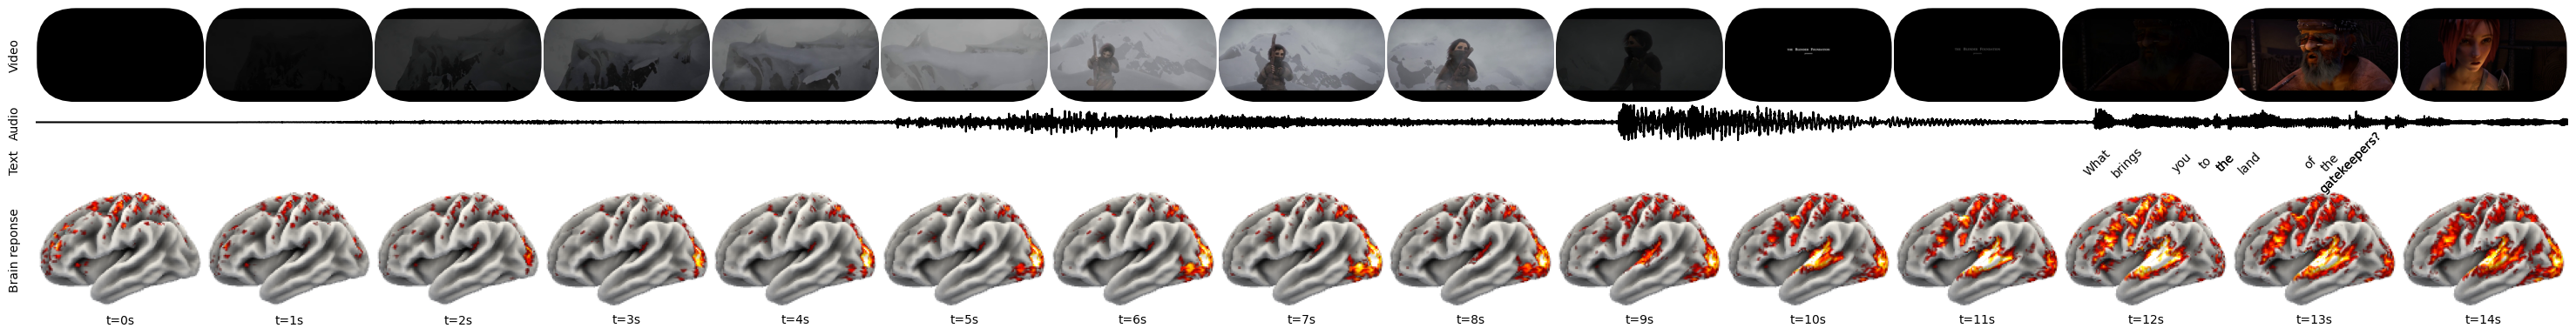

In [6]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [7]:
text = """
To be or not to be, that is the question.
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-To-be-or-not-to-be,-that-is-the-question.-Whether-tis-nobler-in-the-mind-to-suffer-The-slings-and-arrows-of-outrageous-for...11-44470b46/audio.mp3
INFO:tribev2.demo_utils:Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-To-be-or-not-to-be,-that-is-the-question.-Whether-tis-nobler-in-the-mind-to-suffer-The-slings-and-arrows-of-outrageous-for...11-44470b46/audio.mp3
Extracting words from audio: 100%|██████████| 1/1 [00:51<00:00, 51.33s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 60/60 [00:00<00:00, 28330.32it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,23.256000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.090999,1.260002,NaN,To be or not to be.,
2,Text,0.091000,22.607000,NaN,To be or not to be. That is the question. Whet...,
3,Word,0.091000,0.100000,NaN,To,To
4,Word,0.271000,0.200000,NaN,be,To be
5,Word,0.551000,0.060000,NaN,or,To be or
6,Word,0.691000,0.200000,NaN,not,To be or not
7,Word,0.931000,0.100000,NaN,to,To be or not to


### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [8]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[16:03:11 WARNING] Removing extractor video as there are no corresponding events
[16:03:11 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

100%|██████████| 60/60 [00:39<00:00,  1.51it/s]

Computing word embeddings: 100%|██████████| 15/15 [00:39<00:00,  2.64s/it]
[16:03:52 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[16:04:05 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-07-08 16:04:05 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[16:04:05 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.92s/it]
INFO - Predicted 24 / 100 segments (24.0% kept)
INFO:tribev2.demo_utils:Predicted 24 / 100 segments (24.0% kept)


Predictions shape: (24, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  5.84it/s]


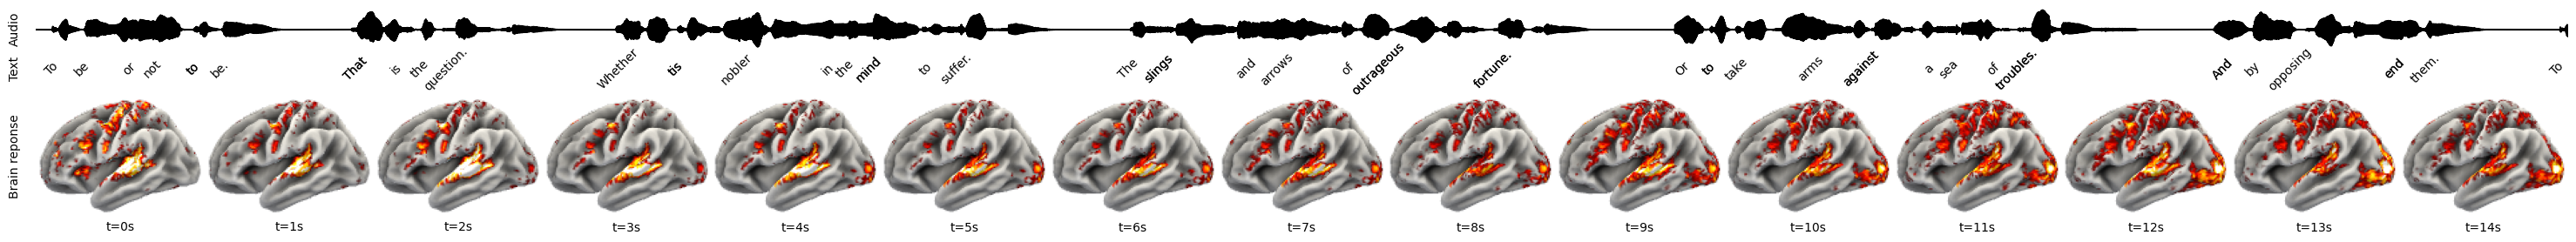

In [9]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

In [10]:
from google.colab import files
up = files.upload()                 # pick example.mp4 from your computer
video_path = next(iter(up))
print("🎬 Using:", video_path)

Saving demo.mp4 to demo.mp4
🎬 Using: demo.mp4


Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in demo.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


Extracting words from audio: 100%|██████████| 1/1 [00:42<00:00, 42.75s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 10/10 [00:00<00:00, 10801.71it/s]


...

[16:35:31 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-07-08 16:35:49 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 35.28s at 30.0fps, shape (854, 480)):
demo.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 35.28s at 30.0fps, shape (854, 480)):
demo.mp4
Encoding video:   0%|          | 0/71 [00:00<?, ?it/s]2026-07-08 16:36:04 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (71, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (71, 20, 1408)
Encoding video: 100%|██████████| 71/71 [18:20<00:00, 15.50s/it]
[16:54:10 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-07-08 16:54:10 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[16:54:11 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 wo

🧠 Predictions shape: (36, 20484)   (n_timesteps, n_vertices)


Plotting...: 100%|██████████| 15/15 [00:02<00:00,  6.36it/s]


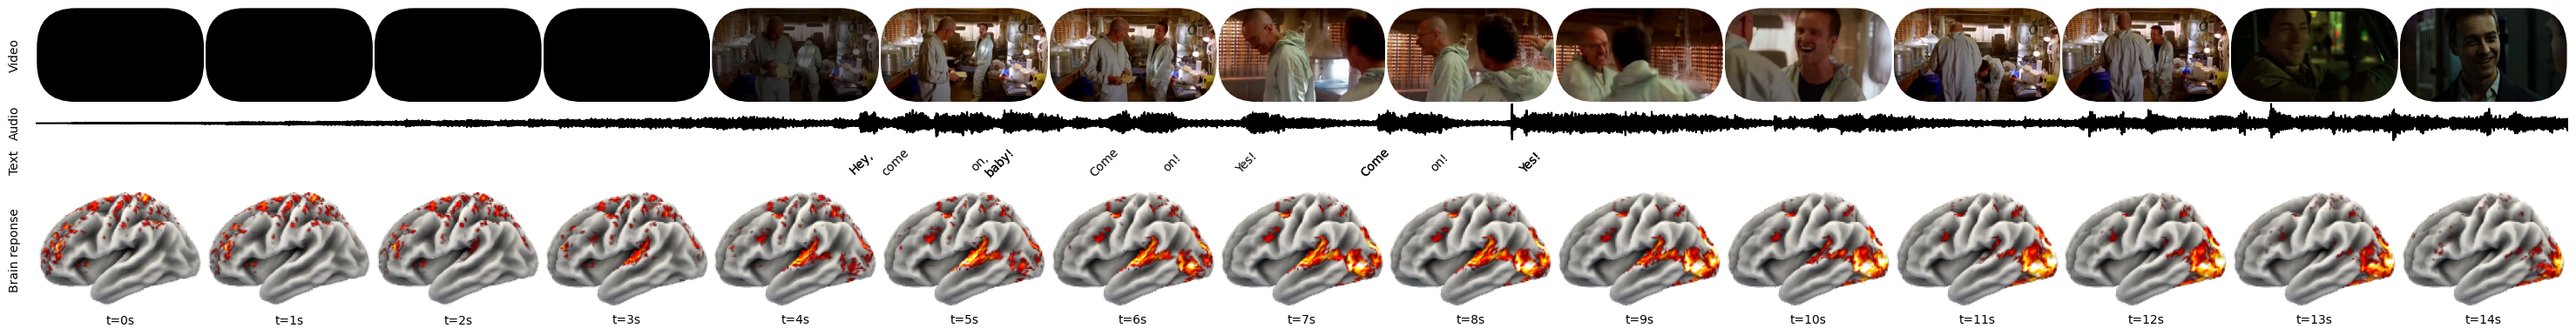

In [11]:
# reuses the model & plotter already loaded above
df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

preds, segments = model.predict(events=df)
print(f"🧠 Predictions shape: {preds.shape}   (n_timesteps, n_vertices)")

n = min(15, len(segments))
fig = plotter.plot_timesteps(
    preds[:n], segments=segments[:n],
    cmap="fire", norm_percentile=99, vmin=.6,
    alpha_cmap=(0, .2), show_stimuli=True,
)

[fetch_atlas_surf_destrieux] Added README.md to /root/nilearn_data

[fetch_atlas_surf_destrieux] Dataset created in /root/nilearn_data/destrieux_surface

[fetch_atlas_surf_destrieux] Downloading data from 
https://www.nitrc.org/frs/download.php/9343/lh.aparc.a2009s.annot ...

[fetch_atlas_surf_destrieux]  ...done. (1 seconds, 0 min)

[fetch_atlas_surf_destrieux] Downloading data from 
https://www.nitrc.org/frs/download.php/9342/rh.aparc.a2009s.annot ...

[fetch_atlas_surf_destrieux]  ...done. (1 seconds, 0 min)

/tmp/ipykernel_10853/1519988475.py:11: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  d = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_10853/1519988475.py:11: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  d = datasets.fetch_atlas_surf_destrieux()


sec | top network   | top region (anatomical)            | activity
------------------------------------------------------------------------
  0 | Somatomotor   | G_and_S_cingul-Mid-Ant (R)         | +0.39
  1 | Somatomotor   | G_and_S_cingul-Mid-Ant (R)         | +0.39
  2 | Somatomotor   | S_temporal_transverse (R)          | +0.52
  3 | Auditory      | S_temporal_transverse (R)          | +0.83
  4 | Auditory      | S_temporal_transverse (R)          | +0.90
  5 | Auditory      | S_temporal_transverse (R)          | +0.98
  6 | Auditory      | S_temporal_transverse (R)          | +0.89
  7 | Auditory      | S_occipital_ant (R)                | +1.08
  8 | Auditory      | S_occipital_ant (R)                | +1.12
  9 | Visual        | S_occipital_ant (R)                | +1.18
 10 | Visual        | S_occipital_ant (R)                | +1.19
 11 | Visual        | S_occipital_ant (R)                | +1.13
 12 | Visual        | S_occipital_ant (R)                | +1.02
 13 | Visual  

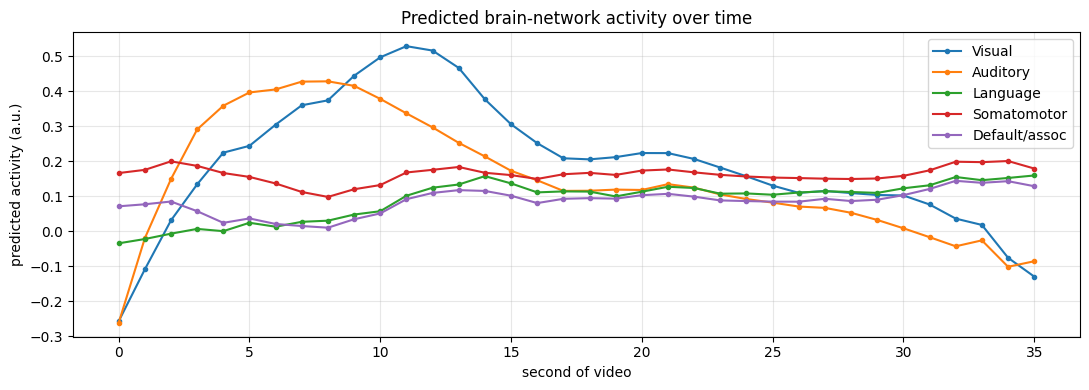

In [12]:
# ============================================================
#  Interpret TRIBE predictions: which brain networks activate, per second
# ============================================================
import numpy as np, matplotlib.pyplot as plt
from collections import defaultdict
from nilearn import datasets

assert 'preds' in dir(), "Run your video cells first so `preds` exists."

# --- 1. Map every cortical point to a named region (Destrieux atlas) ---
d = datasets.fetch_atlas_surf_destrieux()
labels = [l.decode() if isinstance(l, (bytes, bytearray)) else str(l) for l in d['labels']]
lh, rh = np.asarray(d['map_left']), np.asarray(d['map_right'])
assert preds.shape[1] == len(lh) + len(rh), \
    f"preds has {preds.shape[1]} points, atlas has {len(lh)+len(rh)} — paste preds.shape to me"

def region_timecourses(activity, label_map, side):
    out = {}
    for idx in np.unique(label_map):
        name = labels[idx]
        if 'unknown' in name.lower() or 'medial' in name.lower():
            continue
        out[f"{name} ({side})"] = activity[:, label_map == idx].mean(axis=1)
    return out

T = preds.shape[0]
region_ts = {}
region_ts.update(region_timecourses(preds[:, :len(lh)], lh, "L"))
region_ts.update(region_timecourses(preds[:, len(lh):], rh, "R"))

# --- 2. Roll regions up into approximate functional NETWORKS ------------
RULES = [
    ("Visual",       ["occipital","calcarine","cuneus","lingual","fusifor","lunatus","oc-temp_med"]),
    ("Auditory",     ["transv","heschl","plan_tempo","plan_polar","temp_sup"]),
    ("Language",     ["front_inf-opercular","front_inf-triangul","angular","supramar","temporal_middle"]),
    ("Somatomotor",  ["precentral","postcentral","_central","paracentral","subcentral"]),
    ("Default/assoc",["front_sup","front_middle","cingul","precuneus","orbital","rectus"]),
]
def net_of(name):
    n = name.lower()
    for net, keys in RULES:
        if any(k in n for k in keys): return net
    return "Other"

net_sum, net_cnt = defaultdict(lambda: np.zeros(T)), defaultdict(int)
for name, ts in region_ts.items():
    net_sum[net_of(name)] += ts; net_cnt[net_of(name)] += 1
net_ts = {k: net_sum[k]/net_cnt[k] for k in net_sum}

# --- 3. Second-by-second narration -------------------------------------
names = list(region_ts.keys())
mat = np.stack([region_ts[n] for n in names], axis=1)   # (T, regions)
print(f"{'sec':>3} | {'top network':<13} | {'top region (anatomical)':<34} | activity")
print("-"*72)
for t in range(T):
    ri = int(mat[t].argmax())
    nt = max(net_ts, key=lambda k: net_ts[k][t])
    print(f"{t:>3} | {nt:<13} | {names[ri]:<34} | {mat[t, ri]:+.2f}")

print("\nWhen each network peaks:")
for net in ["Visual","Auditory","Language","Somatomotor","Default/assoc"]:
    if net in net_ts:
        print(f"  {net:<13} → strongest at second {int(np.argmax(net_ts[net]))}")

# --- 4. Plot the network dynamics over time ----------------------------
plt.figure(figsize=(11,4))
for net in ["Visual","Auditory","Language","Somatomotor","Default/assoc"]:
    if net in net_ts:
        plt.plot(range(T), net_ts[net], marker='o', ms=3, label=net)
plt.xlabel("second of video"); plt.ylabel("predicted activity (a.u.)")
plt.title("Predicted brain-network activity over time"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [ ]:
  import numpy as np, matplotlib.pyplot as plt
  from collections import defaultdict
  from nilearn import datasets

  assert 'preds' in dir() and preds.ndim == 2, "Run your video cells first (need `preds`)."
  d = datasets.fetch_atlas_surf_destrieux()
  labels = [l.decode() if isinstance(l,(bytes,bytearray)) else str(l) for l in d['labels']]
  lh, rh = np.asarray(d['map_left']), np.asarray(d['map_right'])
  assert preds.shape[1] == len(lh)+len(rh), f"preds {preds.shape[1]} vs atlas {len(lh)+len(rh)}"

  def region_ts(act, lab, side):
      o = {}
      for idx in np.unique(lab):
          nm = labels[idx]
          if 'unknown' in nm.lower() or 'medial' in nm.lower(): continue
          o[f"{nm} ({side})"] = act[:, lab==idx].mean(1)
      return o
  T = preds.shape[0]
  R = {**region_ts(preds[:,:len(lh)], lh, "L"), **region_ts(preds[:,len(lh):], rh, "R")}

  # Emotion/Social grounded in paper Fig 5: TPJ(=angular gyrus) + MTG, plus affective vmPFC/temporal pole
  RULES = [
   ("Visual",        ["occipital","calcarine","cuneus","lingual","fusifor","lunatus","oc-temp_med"]),
   ("Auditory",      ["transv","heschl","plan_polar","temp_sup-lateral","temp_sup-g_t"]),
   ("Emotion/Social",["temporal_middle","angular","pole_temporal","orbital","rectus","subcallosal","cingul-ant"]),
   ("Language",      ["front_inf-opercular","front_inf-triangul","supramar","temp_sup-plan_tempo"]),
   ("Somatomotor",   ["precentral","postcentral","_central","paracentral","subcentral"]),
   ("Default/assoc", ["front_sup","front_middle","precuneus","cingul"]),
  ]
  def net_of(n):
      n = n.lower()
      for net, ks in RULES:
          if any(k in n for k in ks): return net
      return "Other"
  S, C = defaultdict(lambda: np.zeros(T)), defaultdict(int)
  for nm, ts in R.items(): S[net_of(nm)] += ts; C[net_of(nm)] += 1
  NET = {k: S[k]/C[k] for k in S}

  order = ["Visual","Auditory","Emotion/Social","Language","Somatomotor","Default/assoc"]
  plt.figure(figsize=(11, 4.5))
  for net in order:
      if net in NET:
          hot = net == "Emotion/Social"
          plt.plot(range(T), NET[net], marker='o', ms=3, lw=3 if hot else 1.5,
                   zorder=5 if hot else 2, label=net)
  plt.xlabel("second of video"); plt.ylabel("predicted activity (a.u.)")
  plt.title("Predicted network activity — Emotion/Social highlighted (paper Fig 5: TPJ + MTG)")
  plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

  if "Emotion/Social" in NET:
      e = NET["Emotion/Social"]; pk = int(np.argmax(e))
      print(f"🫀 Emotion/Social peaks at second {pk} (activity {e[pk]:+.2f}).")
      contrib = {nm: R[nm][pk] for nm in R if net_of(nm) == "Emotion/Social"}
      top = sorted(contrib, key=contrib.get, reverse=True)[:3]
      print("   Top contributing regions there:", ", ".join(top))

In [ ]:
  # Re-render the demo-style brain strip for ANY time window. No model, no downloads.
  def show_range(start, end, views="left", every=1):
      assert (end - start) % every == 0, "(end-start) must be divisible by `every`"
      sl = slice(start, end)
      plotter.plot_timesteps(
          preds[sl], segments=segments[sl],
          plot_every_k_timesteps=every,
          cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2),
          show_stimuli=True, views=views,
          timestamps=list(range(start, end, every)),   # real seconds, not 0-based
      )

  show_range(15, 30)                 # e.g. seconds 15–30

  # Page through the WHOLE video, 15 seconds per figure:
  CHUNK = 15
  for s in range(0, len(preds), CHUNK):
      show_range(s, min(s + CHUNK, len(preds)))